# Learning rate tuning

In [1]:
import torch

from cs336_basics.training.sgd_optimizer import SGD

def run(lr: float):
    weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
    opt = SGD([weights], lr=lr)
    losses = []

    for t in range(10):
        opt.zero_grad()
        loss = (weights ** 2).mean()
        losses.append(loss.cpu().item())
        loss.backward()
        opt.step()

    return losses

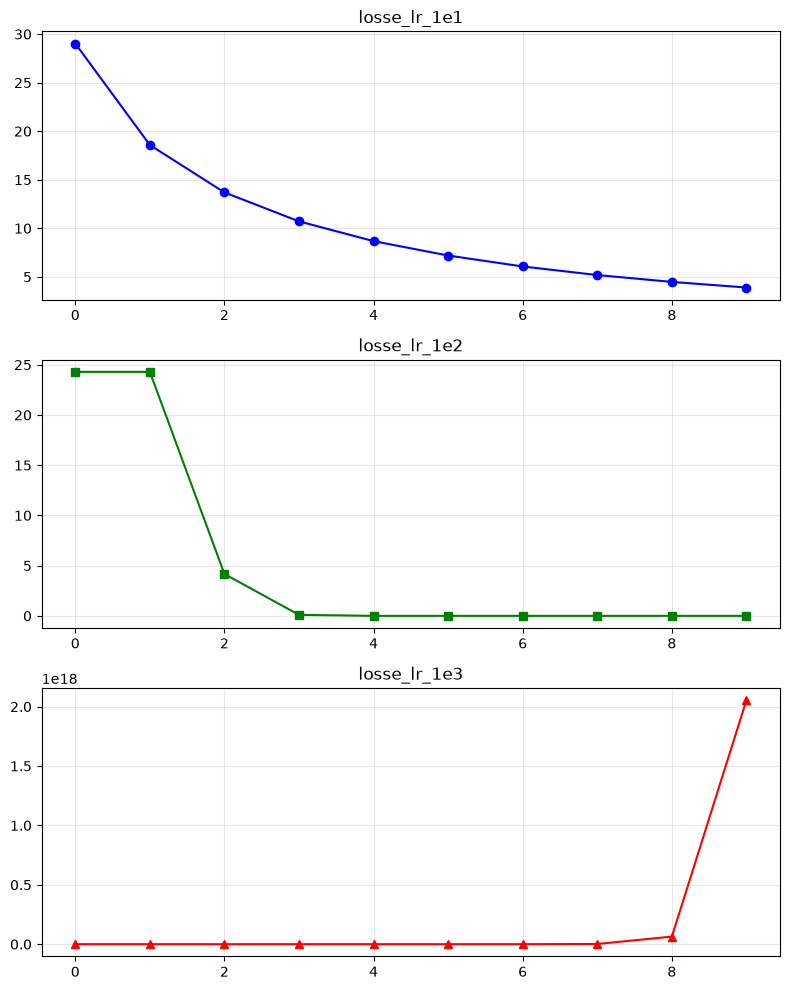

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

# Three lists of floats
losse_lr_1e1 = run(lr=1e1)
losse_lr_1e2 = run(lr=1e2)
losse_lr_1e3 = run(lr=1e3)

# Create subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Plot each list in its own subplot
axes[0].plot(losse_lr_1e1, marker='o', color='blue')
axes[0].set_title('losse_lr_1e1')
axes[0].grid(True, alpha=0.3)

axes[1].plot(losse_lr_1e2, marker='s', color='green')
axes[1].set_title('losse_lr_1e2')
axes[1].grid(True, alpha=0.3)

axes[2].plot(losse_lr_1e3, marker='^', color='red')
axes[2].set_title('losse_lr_1e3')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()